Data generation complete. Saved to 'data/employees_large.csv'

--- Generating Data Visualizations ---


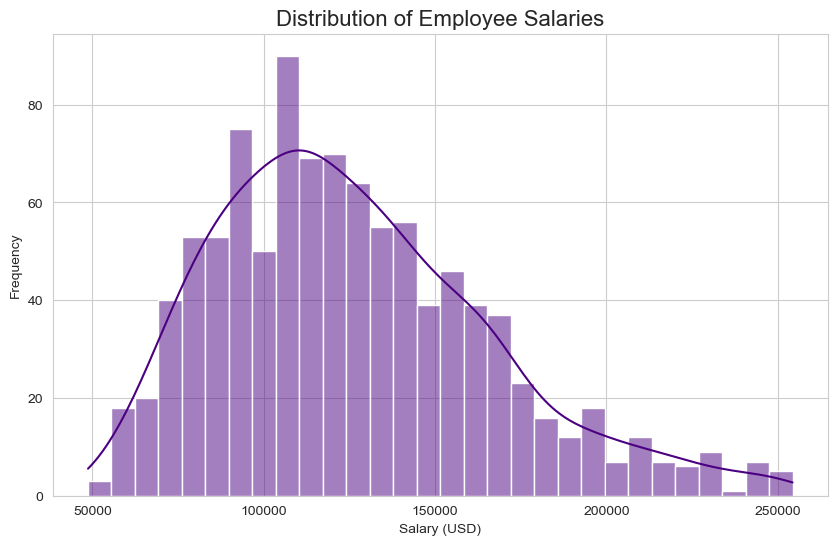

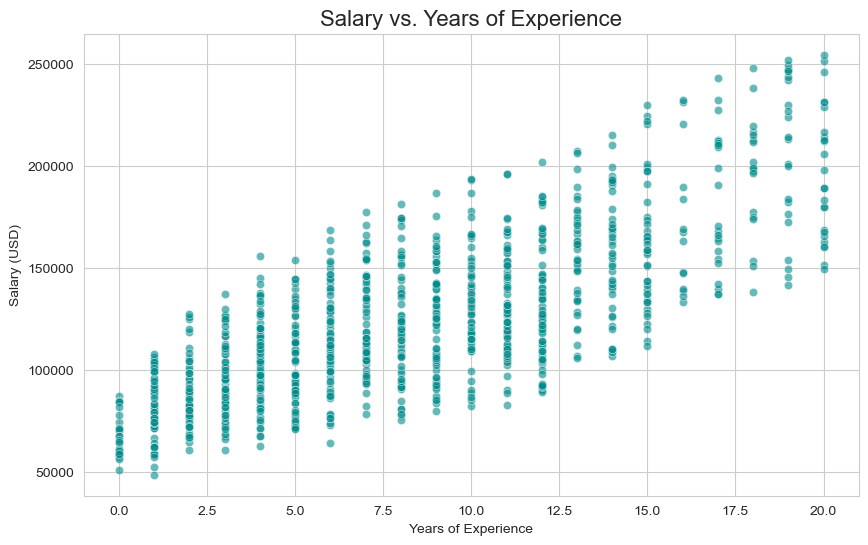

/var/folders/bc/w_wq6y4d0gqfpdt7z1c56czr0000gn/T/ipykernel_1692/2348045997.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='Job Title', x='Salary', data=data, palette='viridis')


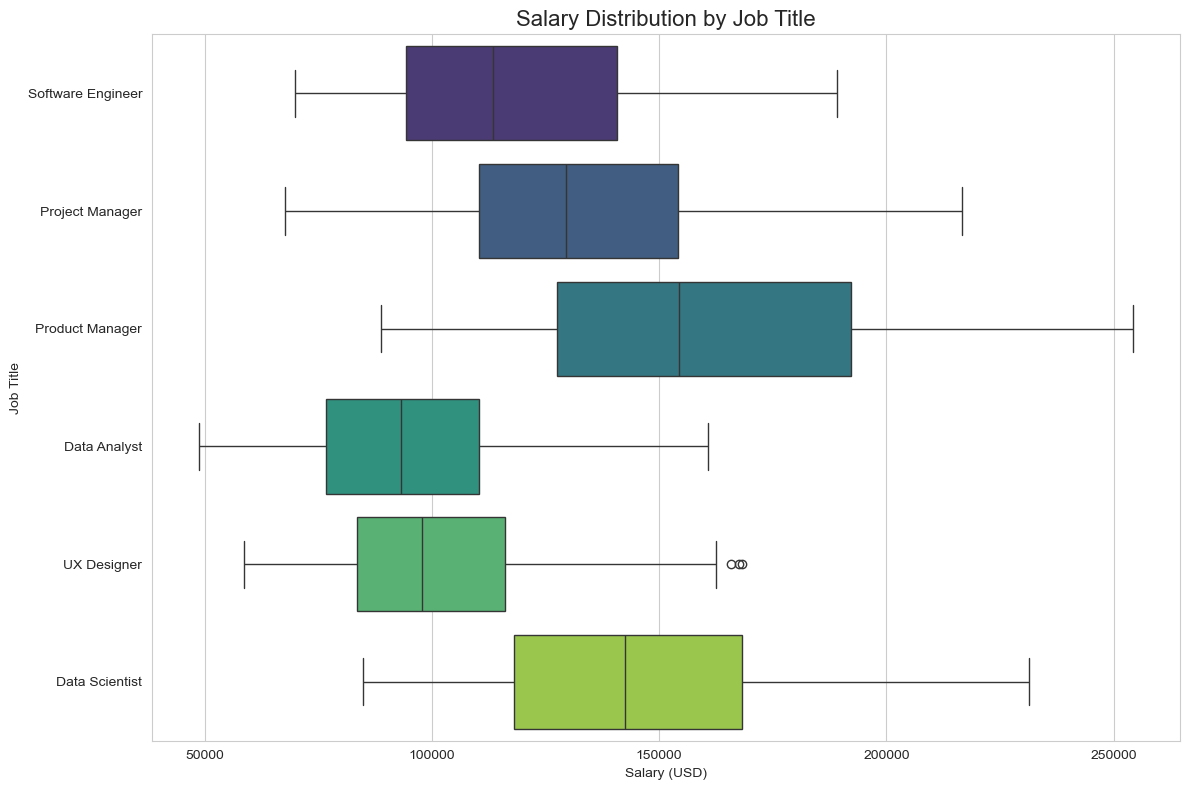

Visualizations saved successfully to the 'plots' folder.

--- Starting Model Training & Optimization ---

--- Final Model Evaluation ---
R^2 Score: 0.9793
MAE: $4,644.01

Model saved successfully.


In [ ]:
import pandas as pd
import numpy as np
import random
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# --- Config... ---
NUM_EMPLOYEES = 1000
JOB_TITLES = {
    "Software Engineer": {"base_salary": 70000, "experience_factor": 3500},
    "Data Scientist": {"base_salary": 85000, "experience_factor": 4500},
    "Product Manager": {"base_salary": 95000, "experience_factor": 5000},
    "UX Designer": {"base_salary": 65000, "experience_factor": 3000},
    "Data Analyst": {"base_salary": 60000, "experience_factor": 2800},
    "Project Manager": {"base_salary": 80000, "experience_factor": 4000}
}
EDUCATION_LEVELS = { "Bachelor's": 1.0, "Master's": 1.15, "PhD": 1.3 }

# --- Part 1: Data Generation ---
def generate_employee_data(num_records):
    records = []
    for _ in range(num_records):
        job_title = random.choice(list(JOB_TITLES.keys()))
        education_level = random.choice(list(EDUCATION_LEVELS.keys()))
        if education_level == "PhD": years_of_experience = random.randint(3, 20)
        elif education_level == "Master's": years_of_experience = random.randint(1, 15)
        else: years_of_experience = random.randint(0, 12)
        age = (22 + years_of_experience) + random.randint(0, 5)
        job_info = JOB_TITLES[job_title]
        salary = (job_info["base_salary"] + (years_of_experience * job_info["experience_factor"])) * EDUCATION_LEVELS[education_level] + np.random.normal(0, 5000)
        records.append({
            "Job Title": job_title, "Years of Experience": years_of_experience,
            "Education Level": education_level, "Age": age, "Salary": int(round(salary, -2))
        })
    return pd.DataFrame(records)

# --- Part 1.5: Data Visualization ---
def visualize_data(data):
    """Generates and saves plots to visualize the dataset."""
    print("\n--- Generating Data Visualizations ---")
    output_dir = 'plots'
    os.makedirs(output_dir, exist_ok=True)
    
    sns.set_style("whitegrid")
    
    # Plot 1: Salary Distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(data['Salary'], kde=True, bins=30, color='indigo')
    plt.title('Distribution of Employee Salaries', fontsize=16)
    plt.xlabel('Salary (USD)')
    plt.ylabel('Frequency')
    plt.savefig(os.path.join(output_dir, 'salary_distribution.png'))
    plt.show()

    # Plot 2: Salary vs. Years of Experience
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='Years of Experience', y='Salary', data=data, alpha=0.6, color='darkcyan')
    plt.title('Salary vs. Years of Experience', fontsize=16)
    plt.xlabel('Years of Experience')
    plt.ylabel('Salary (USD)')
    plt.savefig(os.path.join(output_dir, 'salary_vs_experience.png'))
    plt.show()

    # Plot 3: Salary by Job Title
    plt.figure(figsize=(12, 8))
    sns.boxplot(y='Job Title', x='Salary', data=data, palette='viridis')
    plt.title('Salary Distribution by Job Title', fontsize=16)
    plt.xlabel('Salary (USD)')
    plt.ylabel('Job Title')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'salary_by_job_title.png'))
    plt.show()
    
    print(f"Visualizations saved successfully to the '{output_dir}' folder.")

# --- Part 2: Model Training and Optimization ---
def train_and_save_model(data):
    print("\n--- Starting Model Training & Optimization ---")
    X = data.drop('Salary', axis=1)
    y = data['Salary']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    categorical_features = ['Job Title', 'Education Level']
    numerical_features = ['Years of Experience', 'Age']
    preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)], remainder='passthrough')
    param_grid_rf = {'regressor__n_estimators': [100, 200], 'regressor__max_depth': [10, 20, None]}
    param_grid_gb = {'regressor__n_estimators': [100, 200], 'regressor__learning_rate': [0.05, 0.1]}
    pipeline_rf = Pipeline([('preprocessor', preprocessor), ('regressor', RandomForestRegressor(random_state=42))])
    pipeline_gb = Pipeline([('preprocessor', preprocessor), ('regressor', GradientBoostingRegressor(random_state=42))])
    grid_search_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5, n_jobs=1, scoring='r2')
    grid_search_rf.fit(X_train, y_train)
    grid_search_gb = GridSearchCV(pipeline_gb, param_grid_gb, cv=5, n_jobs=1, scoring='r2')
    grid_search_gb.fit(X_train, y_train)
    best_rf = grid_search_rf.best_estimator_.named_steps['regressor']
    best_gb = grid_search_gb.best_estimator_.named_steps['regressor']
    ensemble_model = VotingRegressor(estimators=[('gb', best_gb), ('rf', best_rf), ('lr', LinearRegression())])
    final_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', ensemble_model)])
    final_pipeline.fit(X_train, y_train)
    y_pred = final_pipeline.predict(X_test)
    print("\n--- Final Model Evaluation ---")
    print(f"R^2 Score: {r2_score(y_test, y_pred):.4f}")
    print(f"MAE: ${mean_absolute_error(y_test, y_pred):,.2f}")
    joblib.dump(final_pipeline, 'salary_prediction_model_enhanced.pkl')
    print("\nModel saved successfully.")

# --- Main Execution ---
if __name__ == "__main__":
    employee_df = generate_employee_data(NUM_EMPLOYEES)
    output_dir = 'data'
    os.makedirs(output_dir, exist_ok=True)
    full_path = os.path.join(output_dir, 'employees_large.csv')
    employee_df.to_csv(full_path, index=False)
    print(f"Data generation complete. Saved to '{full_path}'")
    
    # Call the new visualization function
    visualize_data(employee_df)
    
    train_and_save_model(employee_df)

